# Anomaly Detection on the 40 MHz dataset

Baseline from: https://arxiv.org/pdf/2006.02516.pdf
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

- 56 inputs (18 objects (4 mu, 4 el, 10 jets) x pt, eta, phi + pt and phi of MET)

- The rest is just kept standard for now.
- Embedding: PolynomialEmbedding (n=3)
- Combined loss: $\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \left( \log \left\| P \Phi({X_i}) \right\|_2^2 - 1 \right)^2 + \alpha \cdot \mathrm{ReLU}\left(\log(\|P\|_F^2)\right)$

**Imports**

In [1]:
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import jax
import jax.numpy as jnp
import numpy as np
import optax
from sklearn.metrics import auc
# import tensorflow as tf
from jax.nn.initializers import *
import matplotlib.pyplot as plt
import h5py

from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *

In [2]:
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
jax.config.update("jax_platform_name", 'gpu')

**Load 40 MHz dataset**

In [ ]:
from utils.hep_data import *
inputPath = "/global/cfs/cdirs/m2616/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #This should be false, otherwise there might be issues with reading the hdf5 files.

FALSE


In [4]:
background = LazyH5Array(inputPath+"/background_for_training.h5", "Particles")

In [5]:
print("Background shape before:", background.shape)

Background shape before: (4000000, 56)


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [6]:
# define model parameters
L = 56
initializer = gramschmidt('normal', 1e-1)
key = jax.random.key(42)
shape_method = 'noteven'
bond_dim = 20
phys_dim = (4,4) #This will have to be tuned. dim = polynomial degree + 1
spacing = 8
add_identity = True
boundary='obc'

In [7]:
model = SMPO_initialize(L=L,
                        initializer=initializer,
                        key=key,
                        shape_method=shape_method,
                        spacing=spacing,
                        bond_dim=bond_dim,
                        phys_dim=phys_dim,
                        cyclic=False,
                        compress=True,
                        add_identity=add_identity,
                        boundary=boundary)

In [8]:
alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [9]:
# define training parameters
epochs = 100
batch_size = 10000 # for an order larger batch size, the loss function just doesn't minimize
optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = PolynomialEmbedding(degree=3, n=1, include_bias=True)
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')
device = 'gpu'

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate, device=device)

In [10]:
print("Number of parameters in the model are: ", model.nparams())

Number of parameters in the model are:  110356


In [11]:
history = model.train(background[:2000000],# ran into memory issues when using all 4 million
            epochs=epochs,
            batch_size=batch_size,
            embedding = embedding,
            normalize=True,
            earlystop=earlystop,
            cache=True, # compiling loss function to use it multiple times
            dtype=jnp.float64)

epoch:   3%|▎          3/100 , loss=5506.7023 

Waiting for 1 epochs.


epoch:   4%|▍          4/100 , loss=5719.3496

Waiting for 2 epochs.


epoch:  15%|█▌         15/100 , loss=3247.7829

...

epoch:  30%|███        30/100 , loss=3191.5133

Waiting for 4 epochs.


epoch:  31%|███        31/100 , loss=3228.2092

Training stopped by EarlyStopping on epoch: 26


epoch:  32%|███▏       32/100 , loss=3230.5846


In [12]:
# Save the model after training
save_dir = "saved_models"
model_name = "May6_firstModel"
model.save(model_name, save_dir, tn=True)

ImportError: autoray couldn't find function 'transpose' for backend 'quimb'.

Text(0.5, 1.0, 'Training Loss')

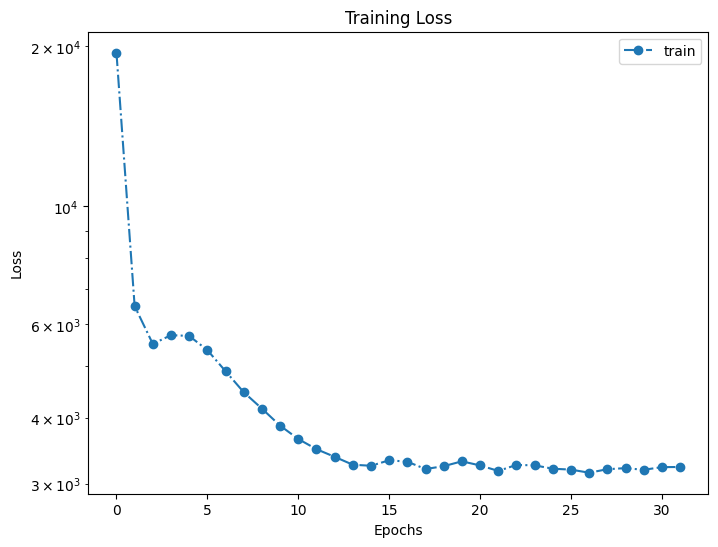

In [15]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='train')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')

**Evaluate**

In [18]:
# Load the signals
bkg_val = h5_to_jax_array(inputPath+"/background_for_training.h5")[:2000000]
lq = h5_to_jax_array(inputPath+"/leptoquark_LOWMASS_lepFilter_13TeV.h5")
a4l = h5_to_jax_array(inputPath+"/Ato4l_lepFilter_13TeV.h5")
htt = h5_to_jax_array(inputPath+"/hToTauTau_13TeV_PU20.h5")
htnu = h5_to_jax_array(inputPath+"/hChToTauNu_13TeV_PU20.h5")

In [19]:
# Run the evaluation on bkg and signals
loss = LogQuadNorm

bkg_score = model.evaluate(bkg_val, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=batch_size, embedding=embedding, metric = loss)
lq_score = model.evaluate(lq, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=batch_size, embedding=embedding, metric = loss)
a4l_score = model.evaluate(a4l, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=batch_size, embedding=embedding, metric = loss)
htt_score = model.evaluate(htt, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=batch_size, embedding=embedding, metric = loss)
htnu_score = model.evaluate(htnu, evaluate_type=train_type, return_list=True, dtype=jnp.float64, batch_size=batch_size, embedding=embedding, metric = loss)

**Plot anomaly scores and ROC curve**

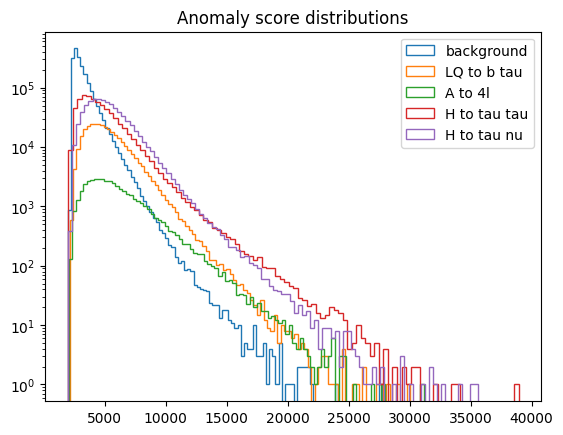

In [20]:
plt.figure()
plt.yscale('log')
plt.hist(bkg_score, bins=100, histtype='step', label='background')
plt.hist(lq_score, bins=100, histtype='step', label='LQ to b tau')
plt.hist(a4l_score, bins=100, histtype='step', label='A to 4l')
plt.hist(htt_score, bins=100, histtype='step', label='H to tau tau')
plt.hist(htnu_score, bins=100, histtype='step', label='H to tau nu')
plt.title('Anomaly score distributions')
plt.legend()
# plt.text(0.5, -0.1, f'AUC Value: {auc_value}', ha='center', transform=plt.gca().transAxes)
plt.legend()
plt.show()

In [21]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

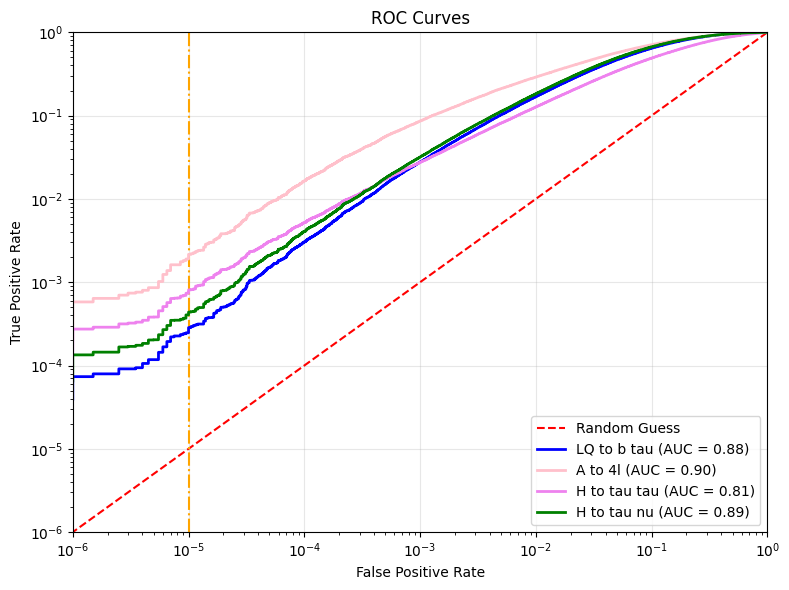

In [22]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.plot([1e-5, 1e-5], [1e-6, 1], color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()